# Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset

In [6]:
df = pd.read_csv("customer_churn_dataset.csv")
df.head()

,CustomerID,Tenure,PreferredLoginDevice,CityTier,WarehouseToHome,PreferredPaymentMode,Gender,HourSpendOnApp,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
0,1,42.0,Computer,3,NaN,Credit Card,Female,3.0,3,Others,5,Married,3,1,32.0,13.0,12.0,18.0,288,1
1,2,36.0,Mobile Phone,3,13.0,UPI,Male,3.0,2,Others,2,Single,1,0,18.0,9.0,10.0,15.0,450,0
2,3,8.0,Tablet,3,46.0,Cash on Delivery,Female,1.0,1,Others,2,Married,1,1,38.0,10.0,2.0,28.0,451,0
3,4,52.0,Computer,3,8.0,Net Banking,Female,3.0,5,Others,3,Married,3,1,40.0,13.0,10.0,7.0,102,0
4,5,34.0,Mobile Phone,2,37.0,UPI,Female,1.0,1,Grocery,1,Divorced,2,0,NaN,3.0,19.0,3.0,90,1


## Dataset Information Check

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5630 entries, 0 to 5629
Data columns (total 20 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   CustomerID                   5630 non-null   int64  
 1   Tenure                       5366 non-null   float64
 2   PreferredLoginDevice         5630 non-null   object 
 3   CityTier                     5630 non-null   int64  
 4   WarehouseToHome              5379 non-null   float64
 5   PreferredPaymentMode         5630 non-null   object 
 6   Gender                       5630 non-null   object 
 7   HourSpendOnApp               5375 non-null   float64
 8   NumberOfDeviceRegistered     5630 non-null   int64  
 9   PreferedOrderCat             5630 non-null   object 
 10  SatisfactionScore            5630 non-null   int64  
 11  MaritalStatus                5630 non-null   object 
 12  NumberOfAddress              5630 non-null   int64  
 13  Complain          

## Statistical Summary

In [8]:
df.describe()

,CustomerID,Tenure,CityTier,WarehouseToHome,HourSpendOnApp,NumberOfDeviceRegistered,SatisfactionScore,NumberOfAddress,Complain,OrderAmountHikeFromlastYear,CouponUsed,OrderCount,DaySinceLastOrder,CashbackAmount,Churn
count,5630.000000,5366.000000,5630.000000,5379.000000,5375.000000,5630.000000,5630.000000,5630.000000,5630.000000,5365.000000,5374.000000,5372.000000,5323.000000,5630.000000,5630.000000
mean,2815.500000,30.282333,2.015275,27.450455,2.506047,3.024156,2.988632,2.481350,0.488988,27.228145,6.975623,9.932427,14.980650,251.188810,0.493783
std,1625.385339,17.060384,0.815410,13.049008,1.122523,1.418147,1.418683,1.109524,0.499923,12.876998,4.311477,5.553257,8.379111,144.594703,0.500006
min,1.000000,1.000000,1.000000,5.000000,1.000000,1.000000,1.000000,1.000000,0.000000,5.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,1408.250000,16.000000,1.000000,16.000000,1.000000,2.000000,2.000000,1.000000,0.000000,16.000000,3.000000,5.000000,8.000000,125.000000,0.000000
50%,2815.500000,30.000000,2.000000,28.000000,3.000000,3.000000,3.000000,2.000000,0.000000,27.000000,7.000000,10.000000,15.000000,253.000000,0.000000
75%,4222.750000,45.000000,3.000000,39.000000,4.000000,4.000000,4.000000,3.000000,1.000000,38.000000,11.000000,15.000000,22.000000,376.000000,1.000000
max,5630.000000,59.000000,3.000000,49.000000,4.000000,5.000000,5.000000,4.000000,1.000000,49.000000,14.000000,19.000000,29.000000,499.000000,1.000000


## Check Missing Values

In [9]:
df.isnull().sum()

CustomerID                       0
Tenure                         264
PreferredLoginDevice             0
CityTier                         0
WarehouseToHome                251
PreferredPaymentMode             0
Gender                           0
HourSpendOnApp                 255
NumberOfDeviceRegistered         0
PreferedOrderCat                 0
SatisfactionScore                0
MaritalStatus                    0
NumberOfAddress                  0
Complain                         0
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
CashbackAmount                   0
Churn                            0
dtype: int64

## Handle Missing Values

In [11]:
df.fillna(df.mean(numeric_only=True), inplace=True)

# fillna() → missing values fill karta hai
# mean() → column ka average value use karta hai

## Remove CustomerID Column

In [12]:
df.drop("CustomerID", axis=1, inplace=True)

## Convert Categorical Data to Numeric

In [13]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df.columns:
    if df[column].dtype == "object":
        df[column] = le.fit_transform(df[column])

## Data Visualization – Churn Distribution

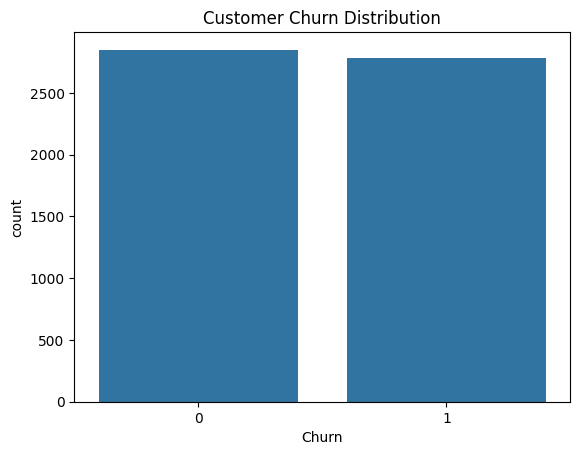

In [14]:
sns.countplot(x="Churn", data=df)

plt.title("Customer Churn Distribution")

plt.show()

## Correlation Heatmap

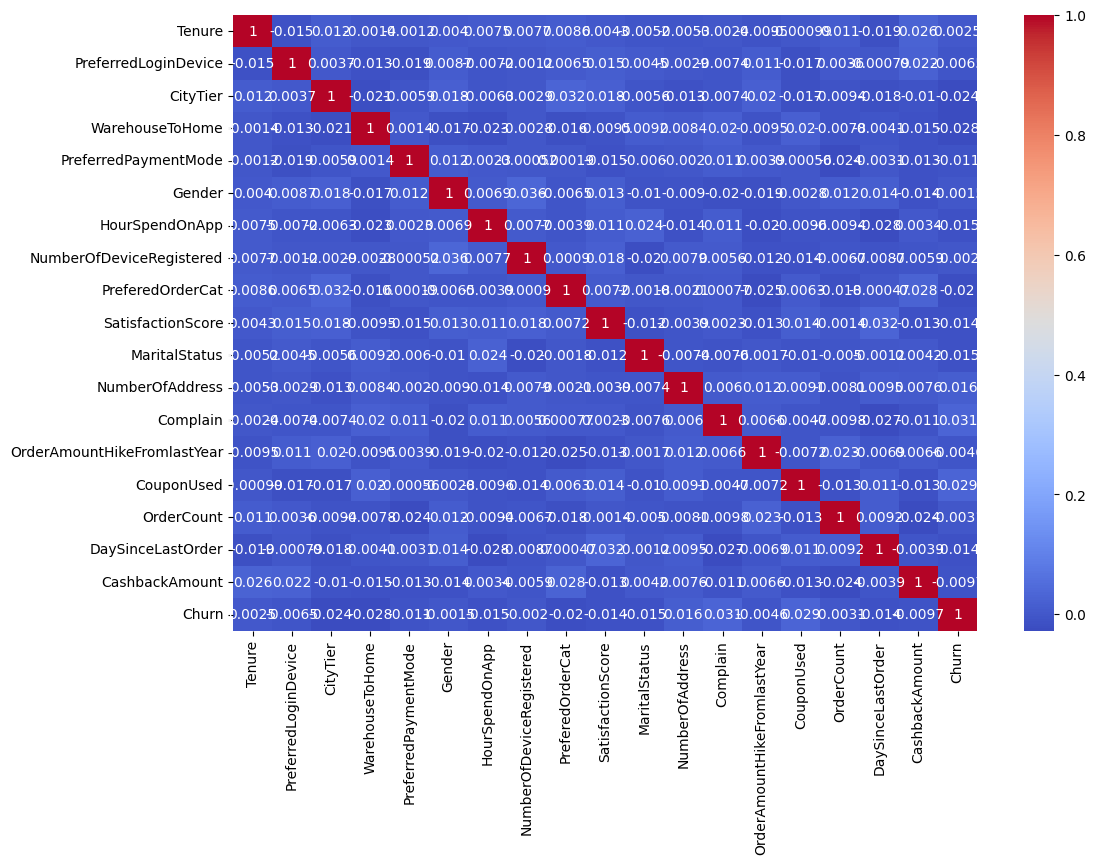

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(), annot=True, cmap="coolwarm")

plt.show()

## Define Features and Target

In [16]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

## Split Dataset (Training & Testing)

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Feature Scaling

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

## Logistic Regression Model

In [19]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

## Prediction

In [20]:
y_pred = model.predict(X_test)

## Model Accuracy

In [21]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.49733570159857904


## Classification Report

In [22]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.52      0.53      0.53       593
           1       0.47      0.46      0.47       533

    accuracy                           0.50      1126
   macro avg       0.50      0.50      0.50      1126
weighted avg       0.50      0.50      0.50      1126



## Confusion Matrix

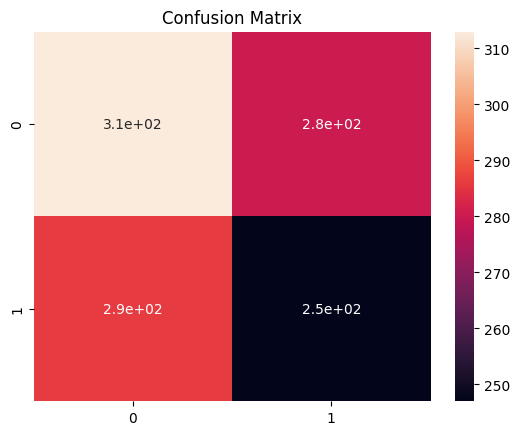

In [23]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)

plt.title("Confusion Matrix")
plt.show()